In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import xarray as xr


In [44]:
#Shape area
shape_area_manning = 6642 * 1000000 # m2

# Load evaporation data from ERA5 #m/day
evap_daily = pd.read_csv("./Data/manning_ERA5_evap_daily.csv")
evap_daily['Date'] = pd.to_datetime(evap_daily['system:index'], format='%Y%m%d')
evap_daily = evap_daily.set_index('Date')[['total_evaporation_sum']].rename(columns={'total_evaporation_sum': 'ERA5_Evaporation'})
# Take absolute value since evaporation is negative in ERA5 data
evap_daily['ERA5_Evaporation'] = evap_daily['ERA5_Evaporation'].abs()

#load precipitation data from ERA5 m/month
precip_daily = pd.read_csv("./Data/manning_ERA5_precip_daily.csv")
precip_daily['Date'] = pd.to_datetime(precip_daily['system:index'], format='%Y%m%d')
precip_daily = precip_daily.set_index('Date')[['total_precipitation_sum']].rename(columns={'total_precipitation_sum': 'ERA5_Precipitation'})      


In [31]:
# Period of interest
experiment_start_time = "2014-01-01T00:00:00Z"
experiment_end_time = "2025-12-31T00:00:00Z"

In [32]:
# fix units of evap and precip data
evap_daily['ERA5_Evaporation'] = evap_daily['ERA5_Evaporation'].abs() * 1000  # Convert m/day to mm/day (already basin-averaged)
precip_daily['ERA5_Precipitation'] = precip_daily['ERA5_Precipitation'] * 1000  # Convert m/day to mm/day (already basin-averaged)

#killawarra station id is 5202080
# Discharge data manning at killawarra station
Obs = pd.read_csv(
    "./Data/5202080_Q_Day.Cmd.txt",
    delimiter=';',
    skiprows=36,
    header=0,
    encoding='cp1252',
    index_col=0,
    parse_dates=True
)
Obs.index.name = 'Day'
Obs = Obs.rename(columns={' Value': 'Q'})  # Note the space before Value
Obs['Q'] = Obs['Q'] * 86400 / shape_area_manning * 1000  # Convert m³/s to mm/day
Obs.loc[Obs['Q'] > 4000, 'Q'] = np.nan
Obs_1 = Obs.loc['1981-01-01':'2025-12-31']
Obs_data = Obs_1['Q'].to_xarray().rename({'Day': 'time'})

In [33]:
precip_xr = precip_daily['ERA5_Precipitation'].to_xarray().rename({'Date': 'time'}).rename('P mm/d')
evap_xr = evap_daily['ERA5_Evaporation'].to_xarray().rename({'Date': 'time'}).rename('EP mm/d')
obs_xr = Obs_data.rename('Q mm/d')

df = xr.merge([precip_xr, evap_xr, obs_xr]).to_dataframe()
data = df[["P mm/d", "EP mm/d", "Q mm/d"]].dropna()
data.index = pd.to_datetime(data.index)

c_pre_deforestation = data.loc["1991-01-01":"2019-12-31"]
c_post_deforestation = data.loc["2020-01-01":"2025-12-31"]
c_pre_deforestation
c_post_deforestation

,P mm/d,EP mm/d,Q mm/d
time,,,
2020-01-01,1.628013,1.681075,0.000013
2020-01-02,0.963744,1.511922,0.000013
2020-01-03,0.093607,1.409883,0.000013
2020-01-04,0.064608,1.178944,0.000000
2020-01-05,2.839272,1.884432,0.000000
...,...,...,...
2025-04-23,13.053404,2.893808,0.623766
2025-04-24,2.133154,2.012947,0.684930
2025-04-25,1.230188,1.773095,1.216728


In [34]:
#calculate et as p - q
c_pre_deforestation["ET mm/d"] = (
    c_pre_deforestation["P mm/d"] - c_pre_deforestation["Q mm/d"]
)

c_post_deforestation["ET mm/d"] = (
    c_post_deforestation["P mm/d"] - c_post_deforestation["Q mm/d"]
)

# Also calculate for the full data
data["ET mm/d"] = data["P mm/d"] - data["Q mm/d"]

#did the budyko change?
P_pre = c_pre_deforestation["P mm/d"].mean()
EP_pre = c_pre_deforestation["EP mm/d"].mean()
ET_pre = c_pre_deforestation["ET mm/d"].mean()

P_post = c_post_deforestation["P mm/d"].mean()
EP_post = c_post_deforestation["EP mm/d"].mean()
ET_post = c_post_deforestation["ET mm/d"].mean()


AI_pre = EP_pre / P_pre
EI_pre = ET_pre / P_pre

AI_post = EP_post / P_post
EI_post = ET_post / P_post


/tmp/ipykernel_327987/4166066476.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_pre_deforestation["ET mm/d"] = (
/tmp/ipykernel_327987/4166066476.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_post_deforestation["ET mm/d"] = (


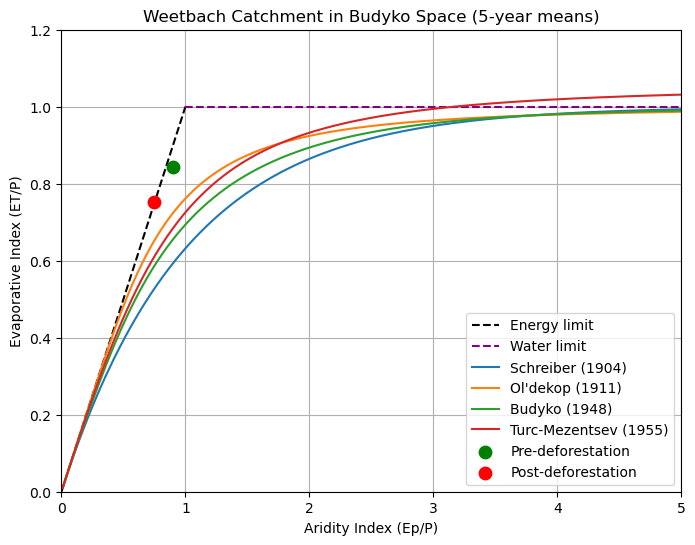

In [35]:
#plot in the budyko framework
plt.figure(figsize=(8,6))
plt.xlim(0, 5)
plt.ylim(0, 1.2)

phi = np.linspace(0.01, 5, 500)

EaP_schreiber = 1 - np.exp(-phi)
EaP_oldekop = phi * np.tanh(1 / phi)
EaP_budyko = np.sqrt(phi * np.tanh(1/phi) * (1 - np.exp(-phi)))
EaP_turc = 1 / np.sqrt(0.9 + (1/phi)**2)



# Energy limit (0–1)
phi_energy = np.linspace(0, 1, 200)
plt.plot(phi_energy, phi_energy, 'k--', label='Energy limit')

# Water limit (1–5)
phi_water = np.linspace(1, 5, 200)
plt.hlines(1, 1, 5, colors='purple', linestyles='--', label='Water limit')

# Analytical curves
plt.plot(phi, EaP_schreiber, label='Schreiber (1904)')
plt.plot(phi, EaP_oldekop, label="Ol'dekop (1911)")
plt.plot(phi, EaP_budyko, label='Budyko (1948)')
plt.plot(phi, EaP_turc, label='Turc-Mezentsev (1955)')

# Pre- and post-deforestation points
plt.scatter(AI_pre, EI_pre, color='green', s=80, label='Pre-deforestation', zorder=5)
plt.scatter(AI_post, EI_post, color='red', s=80, label='Post-deforestation', zorder=5)

plt.xlabel("Aridity Index (Ep/P)")
plt.ylabel("Evaporative Index (ET/P)")
plt.title("Weetbach Catchment in Budyko Space (5-year means)")
plt.legend()
plt.grid(True)
plt.show()


In [36]:
# Interception capacity
Si_max = 2.5  # mm
Si = 0        # initial storage

Pe_list = []
Ei_list = []
Si_list = []

for P, Ep in zip(data["P mm/d"], data["EP mm/d"]):
    
    # 1. Add precipitation
    Si += P
    
    # 2. Throughfall if storage exceeds capacity
    Pe = max(0, Si - Si_max)
    Si -= Pe
    
    # 3. Interception evaporation
    Ei = min(Ep, Si)
    Si -= Ei
    
    # Store results
    Pe_list.append(Pe)
    Ei_list.append(Ei)
    Si_list.append(Si)

# Add to dataframe
data["Pe mm/d"] = Pe_list
data["Ei mm/d"] = Ei_list
data["Si mm"] = Si_list

# Ensure subsets have the new column
c_pre_deforestation["Pe mm/d"] = data.loc[c_pre_deforestation.index, "Pe mm/d"]
c_post_deforestation["Pe mm/d"] = data.loc[c_post_deforestation.index, "Pe mm/d"]
c_pre_deforestation["Si mm"] = data.loc[c_pre_deforestation.index, "Si mm"]
c_post_deforestation["Si mm"] = data.loc[c_post_deforestation.index, "Si mm"]


/tmp/ipykernel_327987/1888514692.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_pre_deforestation["Pe mm/d"] = data.loc[c_pre_deforestation.index, "Pe mm/d"]
/tmp/ipykernel_327987/1888514692.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_post_deforestation["Pe mm/d"] = data.loc[c_post_deforestation.index, "Pe mm/d"]
/tmp/ipykernel_327987/1888514692.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = valu

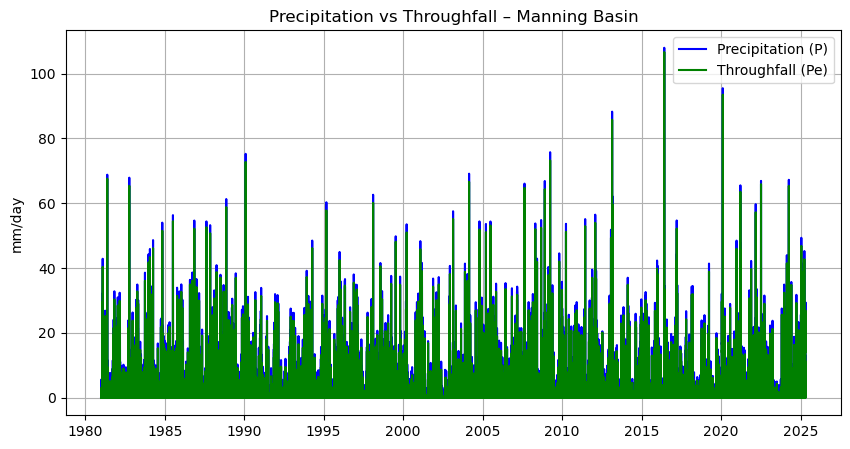

In [37]:

plt.figure(figsize=(10,5))

plt.plot(data.index, data["P mm/d"], label="Precipitation (P)", color="blue")
plt.plot(data.index, data["Pe mm/d"], label="Throughfall (Pe)", color="green")

plt.ylabel("mm/day")
plt.title("Precipitation vs Throughfall – Manning Basin")
plt.legend()
plt.grid(True)
plt.show()


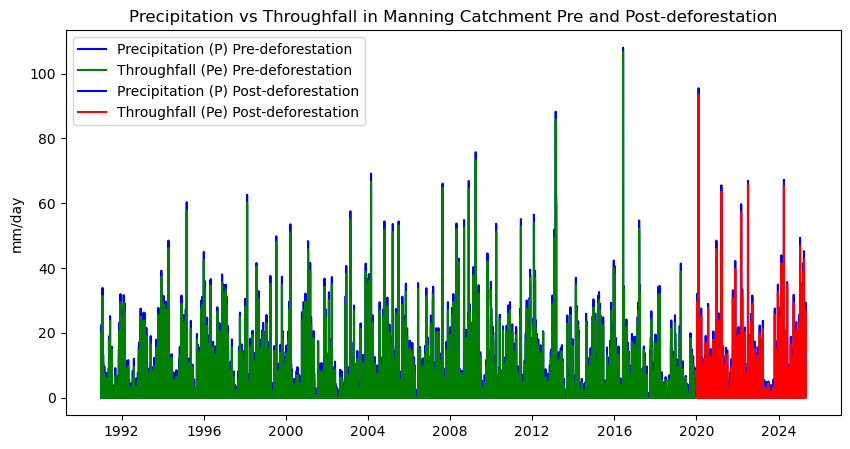

In [38]:
#plot precip v throughfall for pre and post deforestation
plt.figure(figsize=(10,5))  
plt.plot(c_pre_deforestation.index, c_pre_deforestation["P mm/d"], label="Precipitation (P) Pre-deforestation", color="blue")
plt.plot(c_pre_deforestation.index, c_pre_deforestation["Pe mm/d"], label="Throughfall (Pe) Pre-deforestation", color="green")
plt.plot(c_post_deforestation.index, c_post_deforestation["P mm/d"], label="Precipitation (P) Post-deforestation", color="blue")
plt.plot(c_post_deforestation.index, c_post_deforestation["Pe mm/d"], label="Throughfall (Pe) Post-deforestation", color="red")      
plt.ylabel("mm/day")
plt.title("Precipitation vs Throughfall in Manning Catchment Pre and Post-deforestation")
plt.legend()
plt.show()

In [39]:
ratio = data["Pe mm/d"].mean() / data["P mm/d"].mean()
ratio


ratio_pre = c_pre_deforestation["Pe mm/d"].mean() / c_pre_deforestation["P mm/d"].mean()
ratio_post = c_post_deforestation["Pe mm/d"].mean() / c_post_deforestation["P mm/d"].mean()


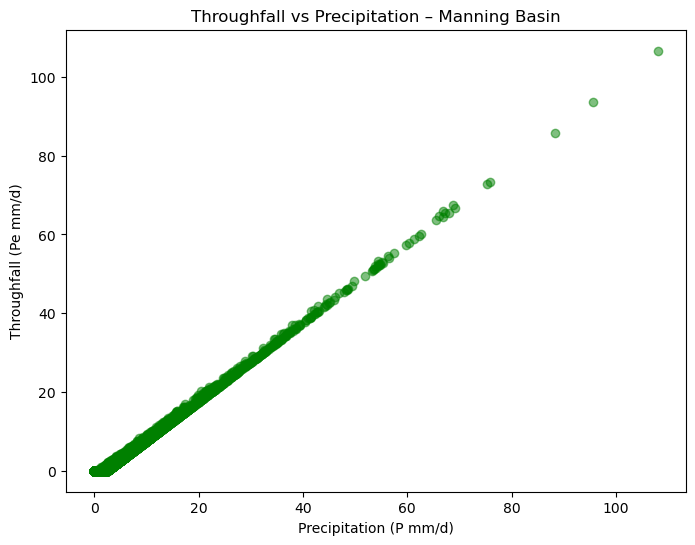

In [40]:
#look at this as a scatter plot of Pe vs P
plt.figure(figsize=(8,6))
plt.scatter(data["P mm/d"], data["Pe mm/d"], alpha=0.5, color='green')
plt.xlabel("Precipitation (P mm/d)")
plt.ylabel("Throughfall (Pe mm/d)")
plt.title("Throughfall vs Precipitation – Manning Basin")
plt.show()

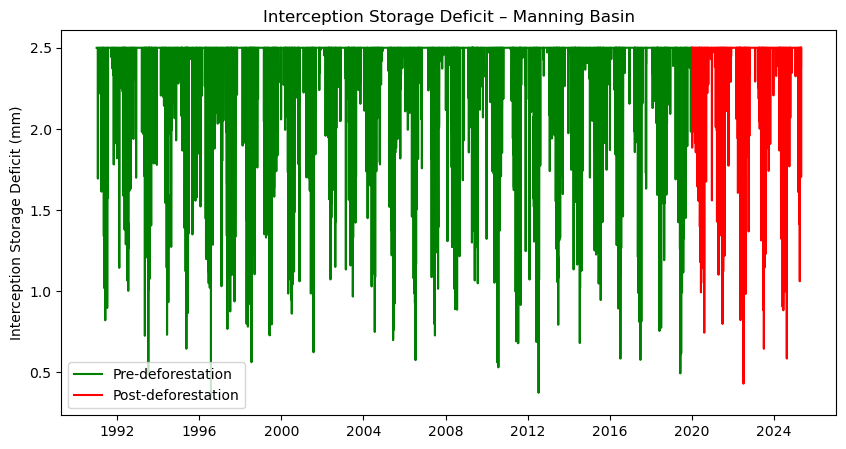

In [41]:
#plot storage deficit per year for pre and post deforestation
plt.figure(figsize=(10,5))
Si_max = 2.5  # mm
plt.plot(c_pre_deforestation.index, Si_max - c_pre_deforestation["Si mm"], label="Pre-deforestation", color="green")
plt.plot(c_post_deforestation.index, Si_max - c_post_deforestation["Si mm"], label="Post-deforestation", color="red")
plt.ylabel("Interception Storage Deficit (mm)")
plt.title("Interception Storage Deficit – Manning Basin")
plt.legend()
plt.show()

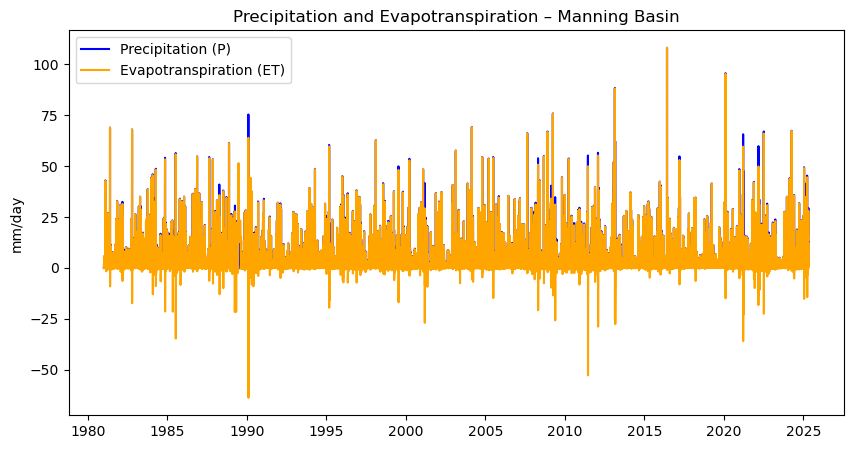

In [42]:
#plot daily precipitation and et as mm/day per year

plt.figure(figsize=(10,5))
plt.plot(data.index, data["P mm/d"], label="Precipitation (P)", color="blue")
plt.plot(data.index, data["ET mm/d"], label="Evapotranspiration (ET)", color="orange")
plt.ylabel("mm/day")
plt.title("Precipitation and Evapotranspiration – Manning Basin")
plt.legend()
plt.show()

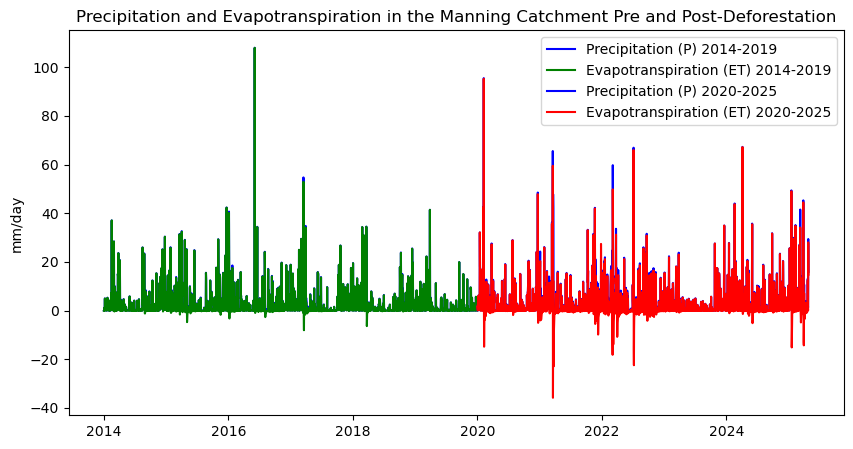

In [43]:
# Filter data to 2014-2025
data_2014_2025 = data.loc["2014-01-01":"2025-12-31"]

# Split into pre and post 2019/2020
pre_2014_2019 = data_2014_2025.loc["2014-01-01":"2019-12-31"]
post_2020_2025 = data_2014_2025.loc["2020-01-01":"2025-12-31"]

plt.figure(figsize=(10,5))

# Plot pre-deforestation (2014-2019)
plt.plot(pre_2014_2019.index, pre_2014_2019["P mm/d"], label="Precipitation (P) 2014-2019", color="blue")
plt.plot(pre_2014_2019.index, pre_2014_2019["ET mm/d"], label="Evapotranspiration (ET) 2014-2019", color="green")

# Plot post-deforestation (2020-2025)
plt.plot(post_2020_2025.index, post_2020_2025["P mm/d"], label="Precipitation (P) 2020-2025", color="blue")
plt.plot(post_2020_2025.index, post_2020_2025["ET mm/d"], label="Evapotranspiration (ET) 2020-2025", color="red")

plt.ylabel("mm/day")
plt.title("Precipitation and Evapotranspiration in the Manning Catchment Pre and Post-Deforestation")
plt.legend()
plt.show()